# ANN

Moreover, it scales
rather well, which has made it possible to train very large foundation models
that can be reused across many different tasks, possibly with a bit of fine-tuning
(that’s transfer learning), or just by prompting the model in the right way (that’s
in-context learning, or ICL). For instance, you can give it a few examples of the
task at hand (that’s few-shot learning, or FSL), or ask it to reason step-by-step
(that’s chain-of-thought prompting, or CoT). 


SVM classification (see the online chapter on SVMs at https://homl.info)

### Perceptron

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2,  0.5], [3, 1]]
y_pred = per_clf.predict(X_new)

In [ ]:
y_pred

array([ True, False])

### Building and Training MLPs with Scikit-Learn

##### Regression MLP

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=42)
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], early_stopping=True, verbose=True, random_state=42)

pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)

Iteration 1, loss = 0.85190332
Validation score: 0.534299
Iteration 2, loss = 0.28288639
Validation score: 0.651094
Iteration 3, loss = 0.22884372
Validation score: 0.699782
Iteration 4, loss = 0.20746145
Validation score: 0.720468
Iteration 5, loss = 0.19649383
Validation score: 0.724839
Iteration 6, loss = 0.18928708
Validation score: 0.740084
Iteration 7, loss = 0.18132029
Validation score: 0.747406
Iteration 8, loss = 0.17556450
Validation score: 0.753945
Iteration 9, loss = 0.17190651
Validation score: 0.760500
Iteration 10, loss = 0.16687650
Validation score: 0.759213
Iteration 11, loss = 0.16329479
Validation score: 0.761907
Iteration 12, loss = 0.16054473
Validation score: 0.768950
Iteration 13, loss = 0.15690181
Validation score: 0.762699
Iteration 14, loss = 0.15630644
Validation score: 0.766003
Iteration 15, loss = 0.15712517
Validation score: 0.778464
Iteration 16, loss = 0.15155981
Validation score: 0.774237
Iteration 17, loss = 0.14957641
Validation score: 0.778361
Iterat

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"[50, 50, ...]"
,activation,'relu'
,solver,'adam'


In [5]:
mlp_reg.best_validation_score_

0.7915361254257781

In [24]:
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5327699946812925

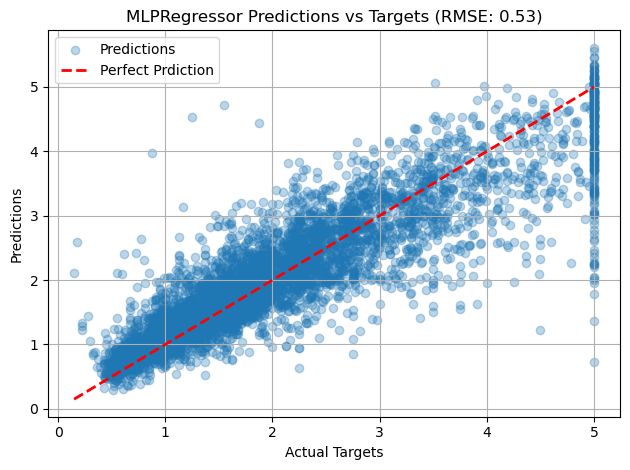

In [25]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.3, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label = 'Perfect Prdiction')
plt.xlabel('Actual Targets')
plt.ylabel('Predictions')
plt.title(f'MLPRegressor Predictions vs Targets (RMSE: {rmse:.2f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
from sklearn.datasets import fetch_openml
fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)

In [2]:
targets = fashion_mnist.target.astype(int)
X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]

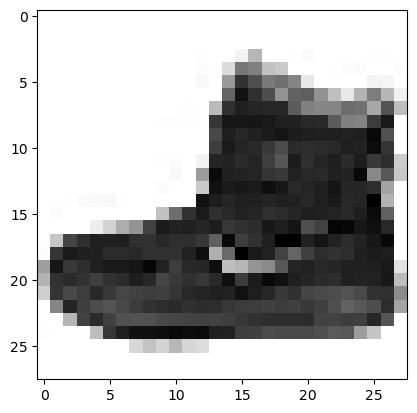

In [3]:
import matplotlib.pyplot as plt 
X_sample = X_train[0].reshape(28, 28)
plt.imshow(X_sample, cmap="binary")
plt.show()

In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [6]:
class_names[y_train[0]]

'Ankle boot'

In [8]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True,
                        early_stopping=True, random_state=42)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

In [9]:
X_new = X_test[:15]
mlp_clf.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4])